In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('Telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


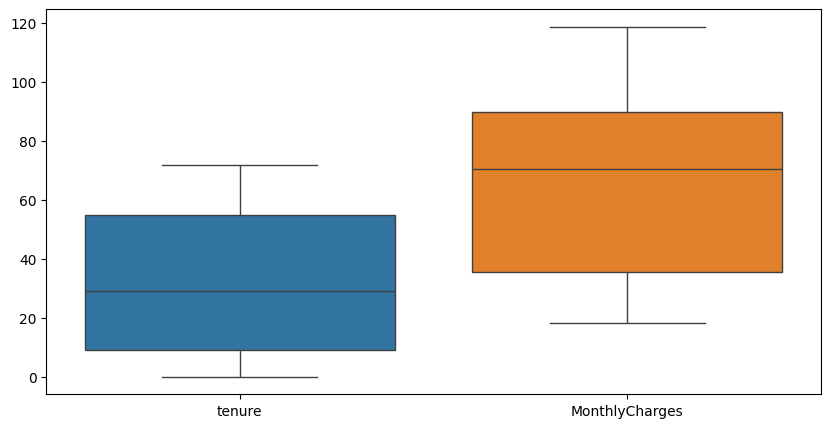

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['tenure', 'MonthlyCharges']])
plt.show()


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


No missing values

In [ ]:
df.duplicated().sum()

np.int64(0)

no duplicates

In [ ]:
df['Churn']=np.where(df['Churn']=='Yes',1,0)
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,0
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,0
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,0


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [ ]:
df.Churn.value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
df=df.drop('customerID',axis=1)

dropping 'customerId' column because it does not contain useful informations for prediction

In [ ]:
df=pd.get_dummies(df,drop_first=True)
df.astype(int)

,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,34,56,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,53,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,45,42,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,70,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84,0,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
7039,0,72,103,0,0,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
7040,0,11,29,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7041,1,4,74,1,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df['MonthlyCharges'].dtypes

dtype('float64')

Machine learning models require numerical input,so categorical variables are converted to numerical variables above

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score


In [ ]:
X=df.drop('Churn',axis=1)
y=df['Churn']


In [ ]:
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [ ]:
model=LogisticRegression(class_weight='balanced')
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

Due to class imbalance in the dataset, class_weight='balanced' was applied in Logistic Regression to give higher importance to churn cases and improve recall.

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.8188627635678574


In [ ]:
y_pred_03 = (y_prob >= 0.35).astype(int)

In [ ]:
confusion_matrix(y_test,y_pred_03)

array([[862, 174],
       [140, 233]])

initial:TN=885,FP=151,FN=160,TP=213

after class weights:TN=862,FP=174,FN=140,TP=233

In [ ]:
print('accuracy:',accuracy_score(y_test,y_pred_03))
print('precision:',precision_score(y_test,y_pred_03))
print('recall:',recall_score(y_test,y_pred_03))
print('f1 score:',f1_score(y_test,y_pred_03))


accuracy: 0.7771469127040455
precision: 0.5724815724815725
recall: 0.6246648793565683
f1 score: 0.5974358974358974


The model shows around 78% accuracy with a recall of 62%.
This means the model is able to detect a majority of churners,
although some are still missed. Improving recall is important
for business since missing churners leads to customer loss.

Applying class weighting and threshold tuning helped to improve
recall, demonstrating the importance of handling imbalanced data.